In [25]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.preprocessing import LabelEncoder

In [26]:
train = pd.read_csv("agnews_clean_train.csv")
val = pd.read_csv("agnews_clean_val.csv")
test = pd.read_csv("agnews_clean_test.csv")
dataset_name = "AG News"
print(train['label'].unique())

[1 0 2 3]


Train label counts:
label
0    4500
1    4500
2    4500
3    4500
Name: count, dtype: int64

Train label proportions:
label
0    0.25
1    0.25
2    0.25
3    0.25
Name: proportion, dtype: float64


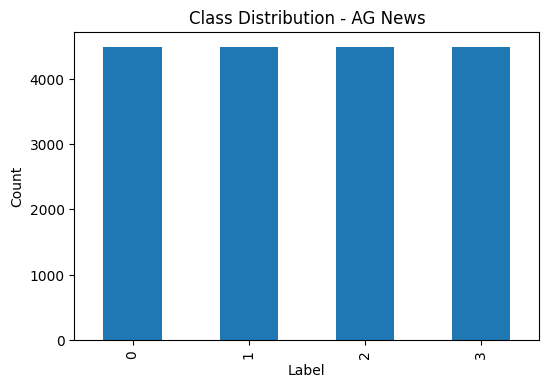

In [27]:
print("Train label counts:")
print(train["label"].value_counts().sort_index())

print("\nTrain label proportions:")
print(train["label"].value_counts(normalize=True).sort_index())

plt.figure(figsize=(6, 4))
train["label"].value_counts().sort_index().plot(kind="bar")
plt.title(f"Class Distribution - {dataset_name}")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

Train text length stats:
count    18000.000000
mean        37.967722
std         10.036575
min          5.000000
50%         37.000000
95%         53.000000
max        142.000000
Name: text_len, dtype: float64


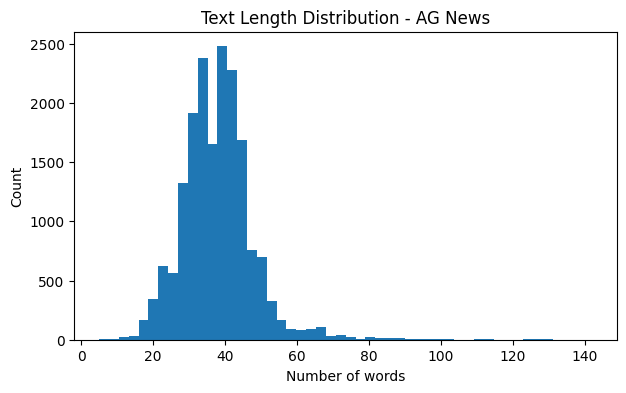

Proportion of training texts longer than 512 words: 0.0000


In [28]:
train["text_len"] = train["text"].apply(lambda x: len(x.split()))
val["text_len"] = val["text"].apply(lambda x: len(x.split()))
test["text_len"] = test["text"].apply(lambda x: len(x.split()))

print("Train text length stats:")
print(train["text_len"].describe(percentiles=[0.5, 0.95]))

plt.figure(figsize=(7, 4))
plt.hist(train["text_len"], bins=50)
plt.title(f"Text Length Distribution - {dataset_name}")
plt.xlabel("Number of words")
plt.ylabel("Count")
plt.show()

over_512 = (train["text_len"] > 512).mean()
print(f"Proportion of training texts longer than 512 words: {over_512:.4f}")

In [29]:
def stratified_subsample(df, label_col="label", frac=1.0, random_state=42):
    if frac == 1.0:
        return df.sample(frac=1, random_state=random_state).reset_index(drop=True)

    sampled_parts = []
    for label, group in df.groupby(label_col):
        n_samples = max(1, int(len(group) * frac))
        sampled_group = group.sample(n=n_samples, random_state=random_state)
        sampled_parts.append(sampled_group)

    sampled_df = (
        pd.concat(sampled_parts)
        .sample(frac=1, random_state=random_state)
        .reset_index(drop=True)
    )
    return sampled_df

In [30]:
def run_logreg(train_df, val_df, test_df, text_col="text", label_col="label"):
    best_f1 = -1
    best_C = None
    best_max_features = None
    best_model = None
    best_vectorizer = None
    best_train_time = None

    for C in [0.1, 1, 10]:
        for max_feat in [10000, 30000, 50000]:
            vectorizer = TfidfVectorizer(
                max_features=max_feat,
                ngram_range=(1, 2)
            )

            X_train = vectorizer.fit_transform(train_df[text_col])
            X_val = vectorizer.transform(val_df[text_col])

            y_train = train_df[label_col]
            y_val = val_df[label_col]

            model = LogisticRegression(C=C, max_iter=1000)

            start_train = time.time()
            model.fit(X_train, y_train)
            train_time = time.time() - start_train

            val_preds = model.predict(X_val)
            val_f1 = f1_score(y_val, val_preds, average="macro")

            if val_f1 > best_f1:
                best_f1 = val_f1
                best_C = C
                best_max_features = max_feat
                best_model = model
                best_vectorizer = vectorizer
                best_train_time = train_time

    X_test = best_vectorizer.transform(test_df[text_col])
    y_test = test_df[label_col]

    start_infer = time.time()
    test_preds = best_model.predict(X_test)
    infer_time = time.time() - start_infer

    test_acc = accuracy_score(y_test, test_preds)
    test_macro_f1 = f1_score(y_test, test_preds, average="macro")
    cls_report = classification_report(y_test, test_preds, output_dict=True)

    return {
        "model_name": "TF-IDF + LogReg",
        "best_C": best_C,
        "best_max_features": best_max_features,
        "accuracy": test_acc,
        "macro_f1": test_macro_f1,
        "train_time": best_train_time,
        "infer_time": infer_time,
        "y_true": np.array(y_test),
        "y_pred": np.array(test_preds),
        "classification_report": cls_report
    }

In [31]:
def run_svm(train_df, val_df, test_df, text_col="text", label_col="label"):
    best_f1 = -1
    best_C = None
    best_max_features = None
    best_model = None
    best_vectorizer = None
    best_train_time = None

    for C in [0.1, 1, 10]:
        for max_feat in [10000, 30000, 50000]:

            vectorizer = TfidfVectorizer(
                max_features=max_feat,
                ngram_range=(1, 2)
            )

            X_train = vectorizer.fit_transform(train_df[text_col])
            X_val = vectorizer.transform(val_df[text_col])

            y_train = train_df[label_col]
            y_val = val_df[label_col]

            model = LinearSVC(C=C)

            start_train = time.time()
            model.fit(X_train, y_train)
            train_time = time.time() - start_train

            val_preds = model.predict(X_val)
            val_f1 = f1_score(y_val, val_preds, average="macro")

            if val_f1 > best_f1:
                best_f1 = val_f1
                best_C = C
                best_max_features = max_feat
                best_model = model
                best_vectorizer = vectorizer
                best_train_time = train_time

    X_test = best_vectorizer.transform(test_df[text_col])
    y_test = test_df[label_col]

    start_infer = time.time()
    test_preds = best_model.predict(X_test)
    infer_time = time.time() - start_infer

    test_acc = accuracy_score(y_test, test_preds)
    test_macro_f1 = f1_score(y_test, test_preds, average="macro")
    cls_report = classification_report(y_test, test_preds, output_dict=True)

    return {
        "model_name": "TF-IDF + SVM",
        "best_C": best_C,
        "best_max_features": best_max_features,
        "accuracy": test_acc,
        "macro_f1": test_macro_f1,
        "train_time": best_train_time,
        "infer_time": infer_time,
        "y_true": np.array(y_test),
        "y_pred": np.array(test_preds),
        "classification_report": cls_report
    }

In [32]:
fractions = [1.0, 0.5, 0.25, 0.1, 0.05, 0.01]
seeds = [42, 123, 456]

all_results = []
all_error_samples = []
all_per_class = []

for frac in fractions:
    for seed in seeds:
        train_sub = stratified_subsample(
            train, label_col="label", frac=frac, random_state=seed
        )

        for run_func in [run_logreg, run_svm]:
            result = run_func(train_sub, val, test, text_col="text", label_col="label")

            all_results.append({
                "dataset": dataset_name,
                "model": result["model_name"],
                "fraction": frac,
                "seed": seed,
                "accuracy": result["accuracy"],
                "macro_f1": result["macro_f1"],
                "train_time": result["train_time"],
                "infer_time": result["infer_time"],
                "best_C": result["best_C"],
                "best_max_features": result["best_max_features"]
            })

            y_true = result["y_true"]
            y_pred = result["y_pred"]

            wrong_mask = y_true != y_pred
            wrong_df = test.loc[wrong_mask, ["text", "label"]].copy()
            wrong_df["pred_label"] = y_pred[wrong_mask]
            wrong_df["dataset"] = dataset_name
            wrong_df["model"] = result["model_name"]
            wrong_df["fraction"] = frac
            wrong_df["seed"] = seed

            all_error_samples.append(wrong_df)

            cls_report = result["classification_report"]
            for cls_name, metrics in cls_report.items():
                if cls_name not in ["accuracy", "macro avg", "weighted avg"]:
                    all_per_class.append({
                        "dataset": dataset_name,
                        "model": result["model_name"],
                        "fraction": frac,
                        "seed": seed,
                        "class": cls_name,
                        "precision": metrics["precision"],
                        "recall": metrics["recall"],
                        "f1": metrics["f1-score"],
                        "support": metrics["support"]
                    })

In [33]:
results_df = pd.DataFrame(all_results)
per_class_df = pd.DataFrame(all_per_class)
error_df = pd.concat(all_error_samples, ignore_index=True)

safe_name = dataset_name.lower().replace(" ", "_")

results_df.to_csv(f"{safe_name}_results_all.csv", index=False)
per_class_df.to_csv(f"{safe_name}_per_class_f1.csv", index=False)
error_df.to_csv(f"{safe_name}_errors.csv", index=False)

print(results_df.head())
print(per_class_df.head())
print(error_df.head())

   dataset            model  fraction  seed  accuracy  macro_f1  train_time  \
0  AG News  TF-IDF + LogReg       1.0    42  0.899342  0.899189    2.286036   
1  AG News     TF-IDF + SVM       1.0    42  0.902500  0.902296    0.246899   
2  AG News  TF-IDF + LogReg       1.0   123  0.899342  0.899189    2.458622   
3  AG News     TF-IDF + SVM       1.0   123  0.902500  0.902296    0.343232   
4  AG News  TF-IDF + LogReg       1.0   456  0.899342  0.899189    2.259747   

   infer_time  best_C  best_max_features  
0    0.002002    10.0              50000  
1    0.001995     1.0              50000  
2    0.002000    10.0              50000  
3    0.001000     1.0              50000  
4    0.002005    10.0              50000  
   dataset            model  fraction  seed class  precision    recall  \
0  AG News  TF-IDF + LogReg       1.0    42     0   0.911875  0.893158   
1  AG News  TF-IDF + LogReg       1.0    42     1   0.942872  0.964211   
2  AG News  TF-IDF + LogReg       1.0    42  

In [34]:
summary_df = (
    results_df.groupby(["dataset", "model", "fraction"])
    .agg(
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        macro_f1_mean=("macro_f1", "mean"),
        macro_f1_std=("macro_f1", "std"),
        train_time_mean=("train_time", "mean"),
        infer_time_mean=("infer_time", "mean")
    )
    .reset_index()
)

summary_df.to_csv(f"{safe_name}_summary.csv", index=False)
summary_df

,dataset,model,fraction,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,train_time_mean,infer_time_mean
0,AG News,TF-IDF + LogReg,0.01,0.722018,0.004078,0.719595,0.005019,0.051730,0.001000
1,AG News,TF-IDF + LogReg,0.05,0.827368,0.001938,0.826098,0.001996,0.549724,0.002449
2,AG News,TF-IDF + LogReg,0.10,0.853640,0.003690,0.852749,0.003754,0.746766,0.001531
3,AG News,TF-IDF + LogReg,0.25,0.875219,0.006144,0.874665,0.006256,0.905037,0.001333
4,AG News,TF-IDF + LogReg,0.50,0.891316,0.000921,0.891025,0.000881,1.375821,0.002501
5,AG News,TF-IDF + LogReg,1.00,0.899342,0.000000,0.899189,0.000000,2.334802,0.002002
6,AG News,TF-IDF + SVM,0.01,0.723026,0.003761,0.720586,0.005041,0.002154,0.000998
7,AG News,TF-IDF + SVM,0.05,0.831360,0.002065,0.830050,0.002222,0.027133,0.001336
8,AG News,TF-IDF + SVM,0.10,0.856886,0.002961,0.855910,0.003016,0.039354,0.001864
9,AG News,TF-IDF + SVM,0.25,0.879605,0.001374,0.879086,0.001381,0.056760,0.001665


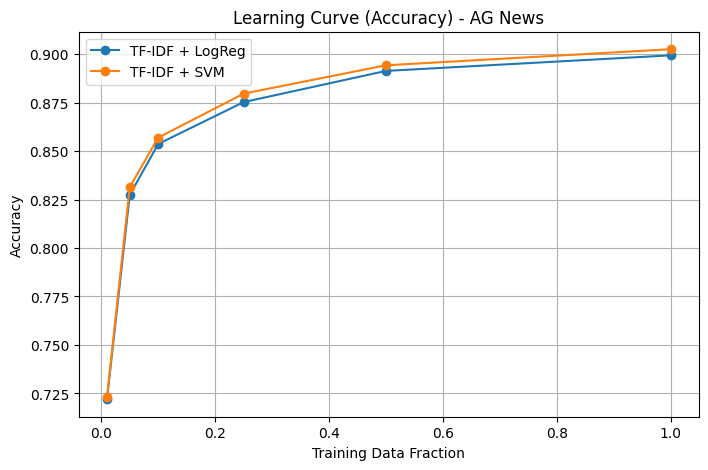

In [35]:
plt.figure(figsize=(8, 5))

for model_name in summary_df["model"].unique():
    temp = summary_df[summary_df["model"] == model_name].sort_values("fraction")
    plt.plot(temp["fraction"], temp["accuracy_mean"], marker="o", label=model_name)

plt.xlabel("Training Data Fraction")
plt.ylabel("Accuracy")
plt.title(f"Learning Curve (Accuracy) - {dataset_name}")
plt.legend()
plt.grid(True)
plt.show()

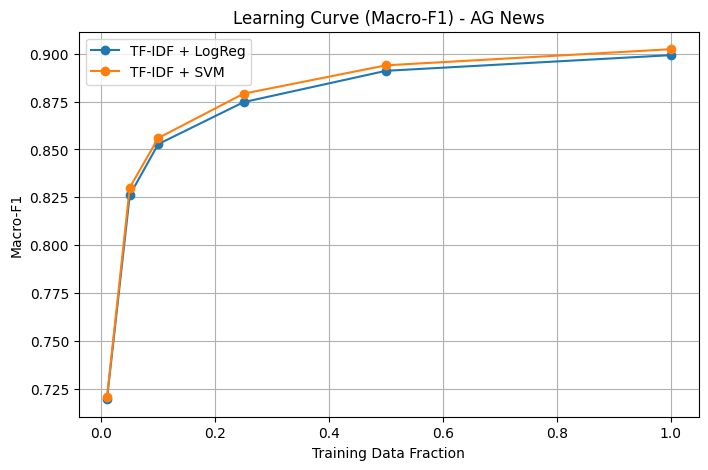

In [36]:
plt.figure(figsize=(8, 5))

for model_name in summary_df["model"].unique():
    temp = summary_df[summary_df["model"] == model_name].sort_values("fraction")
    plt.plot(temp["fraction"], temp["macro_f1_mean"], marker="o", label=model_name)

plt.xlabel("Training Data Fraction")
plt.ylabel("Macro-F1")
plt.title(f"Learning Curve (Macro-F1) - {dataset_name}")
plt.legend()
plt.grid(True)
plt.show()

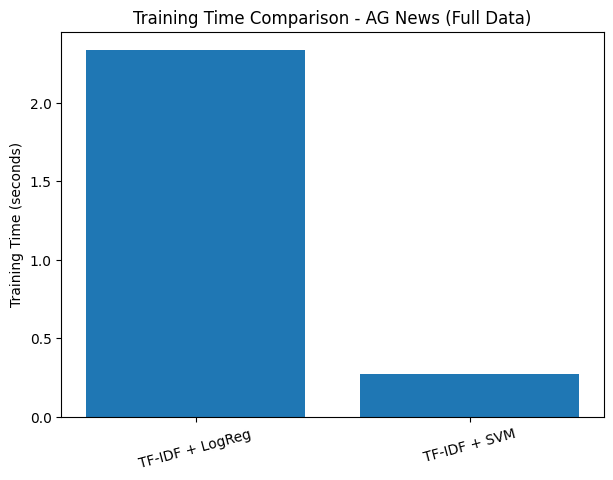

In [37]:
time_plot_df = summary_df[summary_df["fraction"] == 1.0].copy()

plt.figure(figsize=(7, 5))
plt.bar(time_plot_df["model"], time_plot_df["train_time_mean"])
plt.ylabel("Training Time (seconds)")
plt.title(f"Training Time Comparison - {dataset_name} (Full Data)")
plt.xticks(rotation=15)
plt.show()

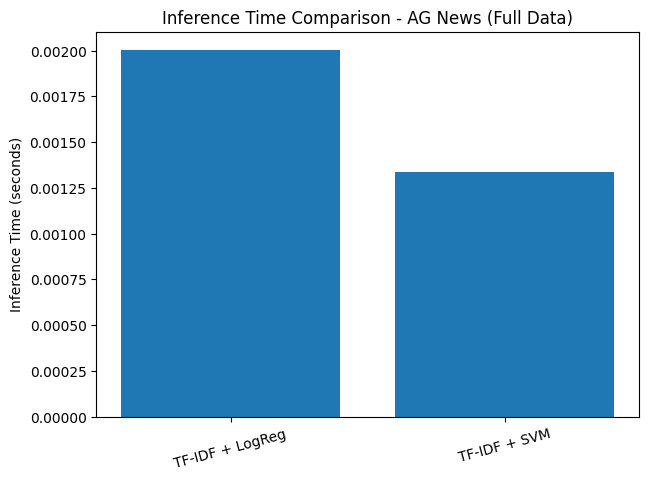

In [38]:
plt.figure(figsize=(7, 5))
plt.bar(time_plot_df["model"], time_plot_df["infer_time_mean"])
plt.ylabel("Inference Time (seconds)")
plt.title(f"Inference Time Comparison - {dataset_name} (Full Data)")
plt.xticks(rotation=15)
plt.show()

In [39]:
per_class_summary = (
    per_class_df.groupby(["dataset", "model", "class", "fraction"])
    .agg(mean_f1=("f1", "mean"))
    .reset_index()
)

full_data_per_class = per_class_summary[per_class_summary["fraction"] == 1.0]

best_worst_list = []
for (dataset, model), group in full_data_per_class.groupby(["dataset", "model"]):
    best_row = group.loc[group["mean_f1"].idxmax()]
    worst_row = group.loc[group["mean_f1"].idxmin()]

    best_worst_list.append({
        "dataset": dataset,
        "model": model,
        "best_class": best_row["class"],
        "best_class_f1": best_row["mean_f1"],
        "worst_class": worst_row["class"],
        "worst_class_f1": worst_row["mean_f1"]
    })

best_worst_df = pd.DataFrame(best_worst_list)
best_worst_df.to_csv(f"{safe_name}_best_worst_class.csv", index=False)
best_worst_df

,dataset,model,best_class,best_class_f1,worst_class,worst_class_f1
0,AG News,TF-IDF + LogReg,1,0.953422,2,0.863612
1,AG News,TF-IDF + SVM,1,0.956950,2,0.866772


In [40]:
focus_errors_logreg = error_df[
    (error_df["model"] == "TF-IDF + LogReg") &
    (error_df["fraction"] == 1.0) &
    (error_df["seed"] == 42)
].copy()

focus_errors_logreg = focus_errors_logreg.head(30)
focus_errors_logreg.to_csv(f"{safe_name}_logreg_top30_errors.csv", index=False)

focus_errors_logreg[["text", "label", "pred_label"]]

,text,label,pred_label
0,Prediction Unit Helps Forecast Wildfires (AP) ...,3,1
1,Rivals Try to Turn Tables on Charles Schwab By...,3,2
2,Venezuela Prepares for Chavez Recall Vote Supp...,0,2
3,Retailers Vie for Back-To-School Buyers (Reute...,2,3
4,Dell Exits Low-End China Consumer PC Market HO...,3,2
5,India's Tata expands regional footprint via Na...,0,2
6,Haas and Cink Selected for Ryder Cup Team Jay ...,1,0
7,Live: Olympics day four Richard Faulds and Ste...,0,1
8,Intel to delay product aimed for high-definiti...,2,3
9,Surviving Biotech's Downturns Charly Travers o...,2,3


In [41]:
focus_errors_svm = error_df[
    (error_df["model"] == "TF-IDF + SVM") &
    (error_df["fraction"] == 1.0) &
    (error_df["seed"] == 42)
].copy()

focus_errors_svm = focus_errors_svm.head(30)
focus_errors_svm.to_csv(f"{safe_name}_svm_top30_errors.csv", index=False)

focus_errors_svm[["text", "label", "pred_label"]]

,text,label,pred_label
765,Prediction Unit Helps Forecast Wildfires (AP) ...,3,1
766,Rivals Try to Turn Tables on Charles Schwab By...,3,2
767,Venezuela Prepares for Chavez Recall Vote Supp...,0,2
768,Retailers Vie for Back-To-School Buyers (Reute...,2,3
769,India's Tata expands regional footprint via Na...,0,2
770,Live: Olympics day four Richard Faulds and Ste...,0,1
771,Intel to delay product aimed for high-definiti...,2,3
772,Surviving Biotech's Downturns Charly Travers o...,2,3
773,Stocks Climb on Drop in Consumer Prices NEW YO...,0,2
774,Yahoo! Ups Ante for Small Businesses Web giant...,2,3


In [42]:
full_data_results = results_df[results_df["fraction"] == 1.0].copy()
full_data_results = full_data_results.sort_values(["model", "seed"]).reset_index(drop=True)

full_data_results

,dataset,model,fraction,seed,accuracy,macro_f1,train_time,infer_time,best_C,best_max_features
0,AG News,TF-IDF + LogReg,1.0,42,0.899342,0.899189,2.286036,0.002002,10.0,50000
1,AG News,TF-IDF + LogReg,1.0,123,0.899342,0.899189,2.458622,0.002000,10.0,50000
2,AG News,TF-IDF + LogReg,1.0,456,0.899342,0.899189,2.259747,0.002005,10.0,50000
3,AG News,TF-IDF + SVM,1.0,42,0.902500,0.902296,0.246899,0.001995,1.0,50000
4,AG News,TF-IDF + SVM,1.0,123,0.902500,0.902296,0.343232,0.001000,1.0,50000
5,AG News,TF-IDF + SVM,1.0,456,0.902500,0.902296,0.233598,0.001009,1.0,50000
